## 14.02节练习参考答案

### 环境准备

In [ ]:
import os, sys
os.environ["TILE_FWK_DEVICE_ID"] = "0"

# 本 notebook 位于 answers/ 子目录下，src 包在其上一级目录。
# 把上层目录加入 sys.path，才能 from src.utils import ...；
# 同时把工作目录切到章节根目录，使 "../data" 数据缓存与主 notebook 一致。
if os.path.isdir("../src"):
    sys.path.insert(0, os.path.abspath(".."))
    os.chdir("..")

import torch
from torch import nn

from src.utils import (TokenEmbedding, Vocab, download_extract,
                       load_array, load_data_imdb, read_imdb, tokenize,
                       train_ch13, truncate_pad, try_all_gpus)
from src.fast_pypto_lstm import FastPyPTOLSTM
from src.pto_layers import PyPTOLinear

batch_size = 64
train_iter, test_iter, vocab = load_data_imdb(batch_size)

本节的解答思路参考了 [《动手学深度学习》习题解答](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/ch15/ch15)，并在此基础上补充了 PyPTO 的实现。

### 练习14.2.1
增加迭代轮数可以提高训练和测试的准确性吗？调优其他超参数怎么样？

**解答：**

增加迭代轮数可以提高训练的准确性，但是不一定能够提高测试的准确性。也可以调节批大小和学习率来观察训练和测试的准确率。

In [2]:
# 使用循环神经网络表示单个文本
class BiRNN(nn.Module):
    def __init__(self, vocab_size, embed_size, num_hiddens,
                 num_layers, **kwargs):
        super(BiRNN, self).__init__(**kwargs)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        # 将bidirectional设置为True以获取双向循环神经网络
        self.encoder = nn.LSTM(embed_size, num_hiddens, num_layers=num_layers,
                                bidirectional=True)
        self.decoder = nn.Linear(4 * num_hiddens, 2)

    def forward(self, inputs):
        # inputs的形状是（批量大小，时间步数）
        # 因为长短期记忆网络要求其输入的第一个维度是时间维，
        # 所以在获得词元表示之前，输入会被转置。
        # 输出形状为（时间步数，批量大小，词向量维度）
        embeddings = self.embedding(inputs.T)
        self.encoder.flatten_parameters()
        # 返回上一个隐藏层在不同时间步的隐状态，
        # outputs的形状是（时间步数，批量大小，2*隐藏单元数）
        outputs, _ = self.encoder(embeddings)
        # 连结初始和最终时间步的隐状态，作为全连接层的输入，
        # 其形状为（批量大小，4*隐藏单元数）
        encoding = torch.cat((outputs[0], outputs[-1]), dim=1)
        outs = self.decoder(encoding)
        return outs


def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)
    if type(m) == nn.LSTM:
        for param in m._flat_weights_names:
            if "weight" in param:
                nn.init.xavier_uniform_(m._parameters[param])


embed_size, num_hiddens, num_layers = 100, 100, 2
devices = try_all_gpus()

迭代次数为5

loss 0.302, train acc 0.870, test acc 0.849
776.9 examples/sec on [device(type='npu', index=0), device(type='npu', index=1)]


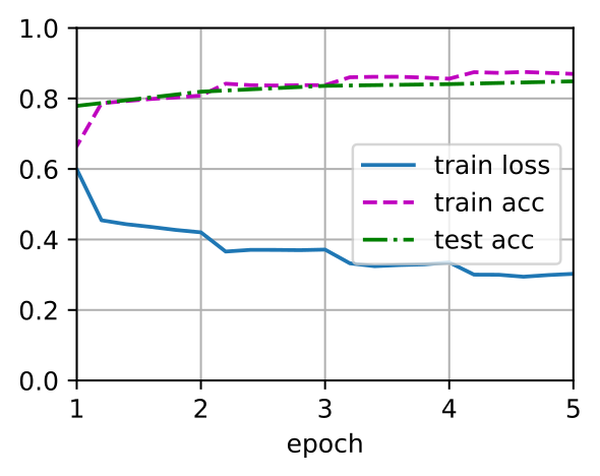

In [3]:
net = BiRNN(len(vocab), embed_size, num_hiddens, num_layers)
net.apply(init_weights)

# 为词表中的单词加载预训练的100维（需要与embed_size一致）的GloVe嵌入。
glove_embedding = TokenEmbedding('glove.6b.100d')
embeds = glove_embedding[vocab.idx_to_token]
net.embedding.weight.data.copy_(embeds)
net.embedding.weight.requires_grad = False

# 训练和评估模型
lr, num_epochs = 0.01, 5  # 学习率为0.01，迭代次数为5
trainer = torch.optim.Adam(net.parameters(), lr=lr)
loss = nn.CrossEntropyLoss(reduction="none")
train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, devices)

迭代次数为10

loss 0.162, train acc 0.939, test acc 0.839
779.4 examples/sec on [device(type='npu', index=0), device(type='npu', index=1)]


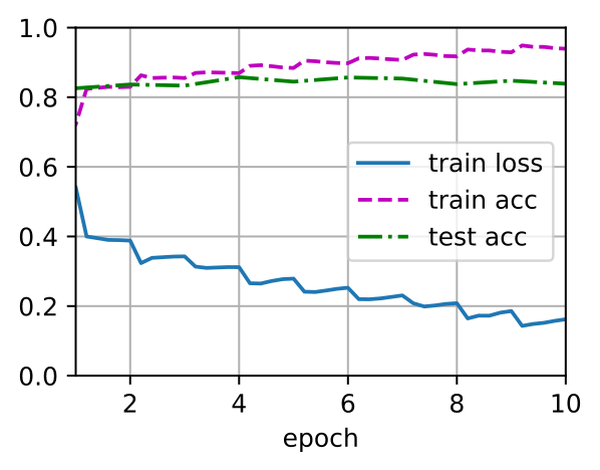

In [4]:
net = BiRNN(len(vocab), embed_size, num_hiddens, num_layers)
net.apply(init_weights)

# 为词表中的单词加载预训练的100维（需要与embed_size一致）的GloVe嵌入。
glove_embedding = TokenEmbedding('glove.6b.100d')
embeds = glove_embedding[vocab.idx_to_token]
net.embedding.weight.data.copy_(embeds)
net.embedding.weight.requires_grad = False

# 训练和评估模型
lr, num_epochs = 0.01, 10  # 学习率为0.01，迭代次数为10
trainer = torch.optim.Adam(net.parameters(), lr=lr)
loss = nn.CrossEntropyLoss(reduction="none")
train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, devices)

迭代次数为20

loss 0.135, train acc 0.947, test acc 0.835
779.5 examples/sec on [device(type='npu', index=0), device(type='npu', index=1)]


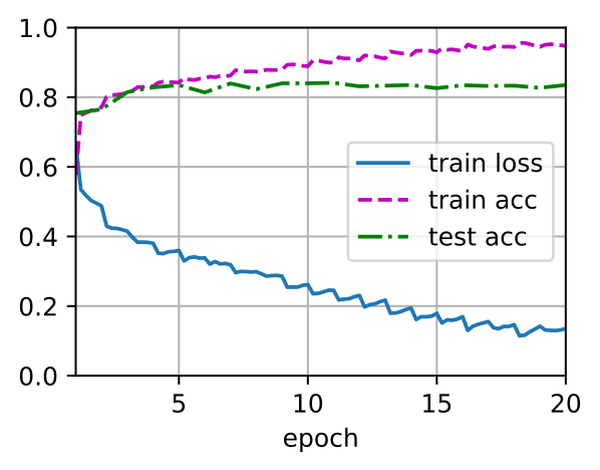

In [9]:
net = BiRNN(len(vocab), embed_size, num_hiddens, num_layers)
net.apply(init_weights)

# 为词表中的单词加载预训练的100维（需要与embed_size一致）的GloVe嵌入。
glove_embedding = TokenEmbedding('glove.6b.100d')
embeds = glove_embedding[vocab.idx_to_token]
net.embedding.weight.data.copy_(embeds)
net.embedding.weight.requires_grad = False

# 训练和评估模型
lr, num_epochs = 0.01, 20  # 学习率为0.01，迭代次数为20
trainer = torch.optim.Adam(net.parameters(), lr=lr)
loss = nn.CrossEntropyLoss(reduction="none")
train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, devices)

- 当迭代次数为5时，训练集精度达到87.0%，此时测试集精度为84.9%
- 当迭代次数为10时，训练集精度达到93.9%，此时测试集精度为83.9%
- 当迭代次数为20时，训练集精度达到94.7%，此时测试集精度为83.5%

因此增加迭代轮数可以提高训练的准确性，但是出现过拟合的情况，降低了在测试集上面的准确性。


loss 0.242, train acc 0.901, test acc 0.872
779.3 examples/sec on [device(type='npu', index=0), device(type='npu', index=1)]


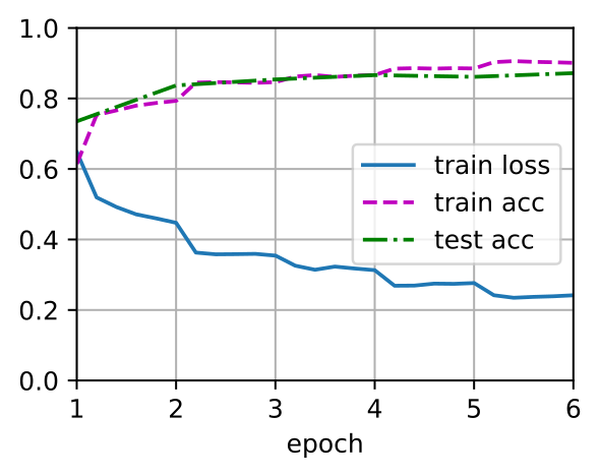

In [8]:
net = BiRNN(len(vocab), embed_size, num_hiddens, num_layers)
net.apply(init_weights)

# 为词表中的单词加载预训练的100维（需要与embed_size一致）的GloVe嵌入。
glove_embedding = TokenEmbedding('glove.6b.100d')
embeds = glove_embedding[vocab.idx_to_token]
net.embedding.weight.data.copy_(embeds)
net.embedding.weight.requires_grad = False

# 训练和评估模型
lr, num_epochs = 0.003, 6  # 学习率为0.003，迭代次数为6
trainer = torch.optim.Adam(net.parameters(), lr=lr)
loss = nn.CrossEntropyLoss(reduction="none")
train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, devices)


减小学习率可以提高测试精度。

**PyPTO 版**(以迭代次数为5为例)

增加迭代轮数可以提高训练的准确性，但是不一定能够提高测试的准确性。也可以调节批大小和学习率来观察训练和测试的准确率。

In [2]:
# 使用循环神经网络表示单个文本
class BiRNN(nn.Module):
    def __init__(self, vocab_size, embed_size, num_hiddens,
                 num_layers, **kwargs):
        super(BiRNN, self).__init__(**kwargs)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        # 将bidirectional设置为True以获取双向循环神经网络
        self.encoder = FastPyPTOLSTM(embed_size, num_hiddens, num_layers=num_layers,
                                bidirectional=True)
        self.decoder = PyPTOLinear(4 * num_hiddens, 2)

    def forward(self, inputs):
        # inputs的形状是（批量大小，时间步数）
        # 因为长短期记忆网络要求其输入的第一个维度是时间维，
        # 所以在获得词元表示之前，输入会被转置。
        # 输出形状为（时间步数，批量大小，词向量维度）
        embeddings = self.embedding(inputs.T)
        self.encoder.flatten_parameters()
        # 返回上一个隐藏层在不同时间步的隐状态，
        # outputs的形状是（时间步数，批量大小，2*隐藏单元数）
        outputs, _ = self.encoder(embeddings)
        # 连结初始和最终时间步的隐状态，作为全连接层的输入，
        # 其形状为（批量大小，4*隐藏单元数）
        encoding = torch.cat((outputs[0], outputs[-1]), dim=1)
        outs = self.decoder(encoding)
        return outs


def init_weights(m):
    if type(m) == PyPTOLinear:
        nn.init.xavier_uniform_(m.weight)
    if type(m) == FastPyPTOLSTM:
        for param in m._flat_weights_names:
            if "weight" in param:
                nn.init.xavier_uniform_(m._parameters[param])


embed_size, num_hiddens, num_layers = 100, 100, 2
devices = try_all_gpus()

迭代次数为5

loss 0.306, train acc 0.870, test acc 0.848
22.1 examples/sec on [device(type='npu', index=0), device(type='npu', index=1)]


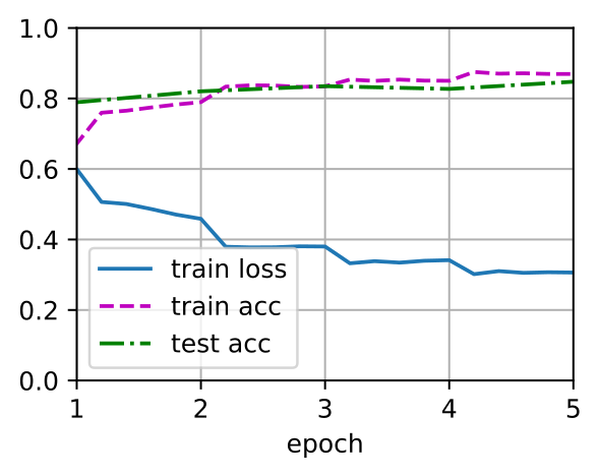

In [3]:
net = BiRNN(len(vocab), embed_size, num_hiddens, num_layers)
net.apply(init_weights)

# 为词表中的单词加载预训练的100维（需要与embed_size一致）的GloVe嵌入。
glove_embedding = TokenEmbedding('glove.6b.100d')
embeds = glove_embedding[vocab.idx_to_token]
net.embedding.weight.data.copy_(embeds)
net.embedding.weight.requires_grad = False

# 训练和评估模型
lr, num_epochs = 0.01, 5  # 学习率为0.01，迭代次数为5
trainer = torch.optim.Adam(net.parameters(), lr=lr)
loss = nn.CrossEntropyLoss(reduction="none")
train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, devices)

减小学习率可以提高测试精度。

### 练习14.2.2
使用较大的预训练词向量，例如300维的GloVe嵌入。它是否提高了分类精度？

**解答：**

官方使用的是100维的Embedding

1. `embed_size, num_hiddens, num_layers = 100, 100, 2`
2. `glove_embedding = TokenEmbedding('glove.6b.100d')`（从 `src.utils` 导入）

**训练结果**
1. loss 0.233, train acc 0.911, test acc 0.852

根据书本14.7.1加载预训练词向量

1. `embed_size, num_hiddens, num_layers = 300, 100, 2` # 注意需要对应embed_size
2. `glove_embedding = TokenEmbedding('glove.42b.300d')` # 42 Billions参数，300维

**训练结果**
1. loss 0.198, train acc 0.923, test acc 0.882


官方示例里，词表中的单词加载预训练的100维（需要与embed_size一致）的GloVe嵌入。

In [10]:
glove_embedding_100 = TokenEmbedding('glove.6b.100d')

loss 0.360, train acc 0.843, test acc 0.833
779.5 examples/sec on [device(type='npu', index=0), device(type='npu', index=1)]


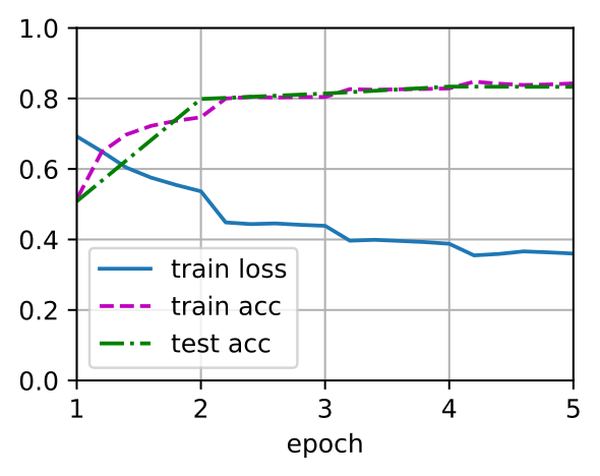

In [11]:
embeds = glove_embedding_100[vocab.idx_to_token]
net.embedding.weight.data.copy_(embeds)
net.embedding.weight.requires_grad = False

# 训练和评估模型
lr, num_epochs = 0.01, 5
net.apply(init_weights)  # 若需多次运行这个cell，需要添加该句语句进行权重刷新
trainer = torch.optim.Adam(net.parameters(), lr=lr)
loss = nn.CrossEntropyLoss(reduction="none")
train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs,
    devices)

修改后，我们为词表中的单词加载预训练的300维（需要与embed_size一致）的GloVe嵌入。

In [12]:
# 修改后，我们为词表中的单词加载预训练的300维（需要与embed_size一致）的GloVe嵌入。
embed_size, num_hiddens, num_layers = 300, 100, 2
net = BiRNN(len(vocab), embed_size, num_hiddens, num_layers)
net.apply(init_weights)

BiRNN(
  (embedding): Embedding(49346, 300)
  (encoder): LSTM(300, 100, num_layers=2, bidirectional=True)
  (decoder): Linear(in_features=400, out_features=2, bias=True)
)

In [13]:
glove_embedding_300 = TokenEmbedding('glove.42b.300d')

正在从 https://d2l-data.s3-accelerate.amazonaws.com/glove.42B.300d.zip 下载 ../data/glove.42B.300d.zip...


loss 0.208, train acc 0.918, test acc 0.859
670.0 examples/sec on [device(type='npu', index=0), device(type='npu', index=1)]


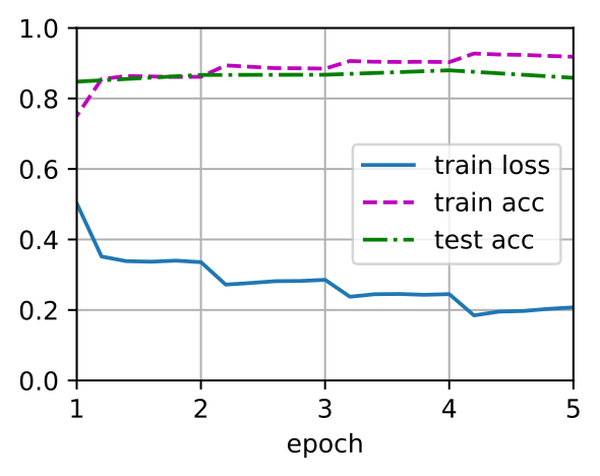

In [14]:
embeds = glove_embedding_300[vocab.idx_to_token]
net.embedding.weight.data.copy_(embeds)
net.embedding.weight.requires_grad = False

# 训练和评估模型
lr, num_epochs = 0.01, 5
net.apply(init_weights)  # 若需多次运行这个cell，需要添加该句语句进行权重刷新
trainer = torch.optim.Adam(net.parameters(), lr=lr)
loss = nn.CrossEntropyLoss(reduction="none")
train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs,
    devices)

综上可知，使用较大的预训练词向量，提高了情感分类精度

1. 使用100维的Embedding，loss = 0.304，train acc = 0.876，test acc = 0.853
2. 使用100维的Embedding，loss = 0.214，train acc = 0.917，test acc = 0.863


### 练习14.2.3
是否可以通过spaCy词元化来提高分类精度？需要安装Spacy（`pip install spacy`）和英语语言包（`python -m spacy download en`）。在代码中，首先导入Spacy（`import spacy`）。然后，加载Spacy英语软件包（`spacy_en = spacy.load('en')`）。最后，定义函数`def tokenizer(text): return [tok.text for tok in spacy_en.tokenizer(text)]`并替换原来的`tokenizer`函数。请注意GloVe和spaCy中短语标记的不同形式。例如，短语标记“new york”在GloVe中的形式是“new-york”，而在spaCy词元化之后的形式是“new york”。

**解答：**

SpaCy 是一个免费的开源库，用于 Python 中的高级自然语言处理包括但不限于词性标注、dependency parsing、NER和相似度计算。它可帮助构建处理和理解大量文本的应用程序可用于多种方向，例如信息提取、自然语言理解或为深度学习提供文本预处理。我们使用spaCy库实现标记化包括将文本分割成单词、标点符号等。这是通过应用特定于每种语言的规则来完成的。

In [ ]:
# spaCy 3.x 中 `python -m spacy download en` 只是 `en_core_web_sm` 的旧别名，
# 且该模型包不在 PyPI 镜像源里（spaCy 会去 GitHub Releases 下载，网络慢时长时间无响应）。
# 直接从 GitHub release URL 安装更可靠：
%pip install --user "https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl"


以下是完整可运行代码

In [20]:
# 编写tokenize2,使用spacy进行分词

import spacy  # 按照题目提示先安装好
spacy_en = spacy.load("en_core_web_sm")


def tokenize1(text): 
    return [tok.text for tok in spacy_en.tokenizer("".join(text))]  # 在官方提供示例基础上，稍作修改


def tokenize2(lines, token='word'):
    if token == 'word':
        return [tokenize1(line) for line in lines]
    elif token == 'char':
        return [list(line) for line in lines]
    else:
        print('ERROR: unknown token type: ' + token)

In [21]:
# 查看两种token方式的区别
doc = ["This new-york is a sentence.", "df", "df df"]
train_tokens = tokenize(doc, token='word')
print(train_tokens)
train_tokens = tokenize2(doc, token='word')  # 自己编写的tokenize2函数
print(train_tokens)

[['This', 'new-york', 'is', 'a', 'sentence.'], ['df'], ['df', 'df']]
[['This', 'new', '-', 'york', 'is', 'a', 'sentence', '.'], ['df'], ['df', 'df']]


In [22]:
def load_data_imdb(batch_size, num_steps=500):
    """使用 spaCy 词元化读入 IMDb 数据（覆盖上方从 utils 导入的同名函数）。

    Defined in :numref:`sec_sentiment`"""
    data_dir = download_extract('aclImdb', 'aclImdb')
    train_data = read_imdb(data_dir, True)
    test_data = read_imdb(data_dir, False)
    train_tokens = tokenize2(train_data[0], token='word')
    test_tokens = tokenize2(test_data[0], token='word')
    vocab = Vocab(train_tokens, min_freq=5)
    train_features = torch.tensor([truncate_pad(
        vocab[line], num_steps, vocab['<pad>']) for line in train_tokens])
    test_features = torch.tensor([truncate_pad(
        vocab[line], num_steps, vocab['<pad>']) for line in test_tokens])
    train_iter = load_array((train_features, torch.tensor(train_data[1])),
                            batch_size)
    test_iter = load_array((test_features, torch.tensor(test_data[1])),
                           batch_size,
                           is_train=False)
    return train_iter, test_iter, vocab

In [23]:
batch_size = 64
train_iter, test_iter, vocab = load_data_imdb(batch_size)  # 使用修改后的 load_data_imdb 函数，加载相关数据

In [24]:
# spaCy 词元化后词表发生变化，重新创建100维模型
embed_size, num_hiddens, num_layers = 100, 100, 2
net = BiRNN(len(vocab), embed_size, num_hiddens, num_layers)
net.apply(init_weights)

glove_embedding_100 = TokenEmbedding('glove.6b.100d')

loss 0.258, train acc 0.899, test acc 0.872
777.6 examples/sec on [device(type='npu', index=0), device(type='npu', index=1)]


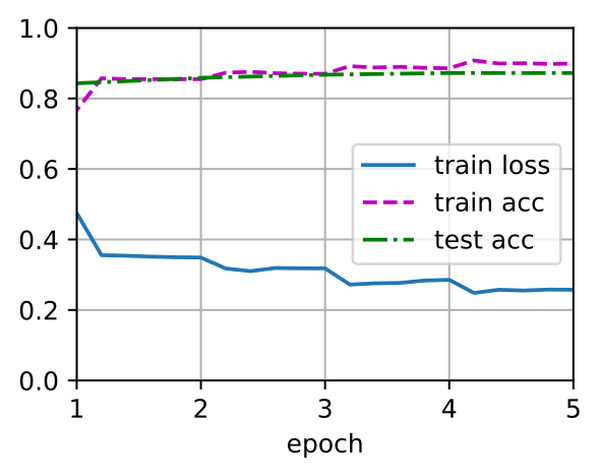

In [25]:
embeds = glove_embedding_100[vocab.idx_to_token]
net.embedding.weight.data.copy_(embeds)
net.embedding.weight.requires_grad = False

# 训练和评估模型
lr, num_epochs = 0.01, 5
net.apply(init_weights)  # 若需多次运行这个cell，需要添加该句语句进行权重刷新
trainer = torch.optim.Adam(net.parameters(), lr=lr)
loss = nn.CrossEntropyLoss(reduction="none")
train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs,
    devices)

综上可知，使用spaCy词元化，提高了情感分类精度

1. 使用默认的tokenize函数，loss = 0.304，train acc = 0.876，test acc = 0.853
2. 使用修改后的tokenize函数，loss = 0.270，train acc = 0.890，test acc = 0.867
